## Tools

In [1]:
from tools.tools import search_resources

/home/migueldcarvalho/miniforge3/envs/chatbot/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


### Descrição de tools

In [2]:
from utils import read_yaml

my_tools = [search_resources] #, Final_answer]

tools = []
my_tools = [search_resources]
tools_description = read_yaml(path="tools/tools_description.yaml")

for tool in my_tools:
    tools.append(tools_description.get(tool.__name__))


## Carrgando modelos

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

In [ ]:
# ============================= Carregando modelo ============================

models = ["Qwen/Qwen2.5-0.5B-Instruct", "Qwen/Qwen3-0.6B", "Qwen/Qwen2.5-Coder-0.5B-Instruct", "Qwen/Qwen3-4B-Instruct-2507"]
model_name = models[3]

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype="auto",
    device_map="auto",
    trust_remote_code=True # Recomendado para modelos Qwen/comunidade
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

## Grafo

### Exibir grafo

In [2]:
from langchain_core.messages import BaseMessage   # Classe pai que dá origem a todos os tipos de messagem no langchain
from langchain_core.messages import ToolMessage   # Classe que gerencia messagens/respotas das tools
from langchain_core.messages import HumanMessage
from langchain_core.messages import AIMessage
from langchain_core.messages import SystemMessage 

from icecream import ic

def role(message: BaseMessage)-> str:
    if isinstance(message, HumanMessage):
        return "user"
    else:
        return "assistant"

def show_messages(messages: list)-> None:
    
    for message in messages:
        if isinstance(message, AIMessage):
            ic(message.content)
        elif isinstance(message, ToolMessage):
            ic(message.content)
        elif isinstance(message, HumanMessage):
            ic(message.content)
        elif isinstance(message, SystemMessage):
            ic(message.content)
        else:
            ic(f"Não é uma BaseMessage: {type(message)} {message}")

### Grafo

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from langgraph.prebuilt import ToolNode # Classe que chama tools
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
# add_message é uma reduce_function, função que dita como um dado será modificado ao ser atualizado
# Nesse caso, add_message concatena messagens anteriores com novas sem reescrever dados anteriores

from langchain_core.messages import BaseMessage   # Classe pai que dá origem a todos os tipos de messagem no langchain
from langchain_core.messages import ToolMessage   # Classe que gerencia messagens/respotas das tools
from langchain_core.messages import HumanMessage
from langchain_core.messages import AIMessage
from langchain_core.messages import SystemMessage # Classe que gerencia messagens de sistema, ordens a LLM
from langchain_core.runnables import RunnableConfig

from typing import TypedDict, Dict
from typing import Annotated # Adiciona decrição a variaveis, variavel = Annotaded[tipo_variavel, "descrição"]
from typing import Sequence  # Cria uma sequência dado um tipo EX: Sequence[int], Sequence[str]...

#from tools.tools import search_resources
from llm import LLM
from utils import read_yaml

from icecream import ic

# Herda da classe TypedDict, permite declarar tipos para classe
# Esta classe serve para gerenciar o estado atual do agente
''' Ver mais informações nas importações de cada função/classe''' 
# Esse tipo de classe não deve ser instanciada, serve como um blueprint para criação e gerenciamento de dicionarios
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages] # Troca de messagens entre chat e usuário
    gov_resources: Annotated[Sequence[ToolMessage], add_messages] # Recursos do governo
    # tipo da variavel messages: sequence[BaseMessages]
    # conteudo: add_messages

def init_state(state: AgentState, config: RunnableConfig):
    print('Inicializando...')
    models = config.get('configurable')
    config.get('configurable').update({'llm_wrapper':LLM(model=models['llm'], tokenizer=models['tokenizer'])})
    return {'messages': [],
            'gov_resources': [ToolMessage(content="", tool_call_id="init")]}

import uuid
def messages_router(func_name: str, result: BaseMessage)->dict:
    if func_name in ["search_resources"]:
        return {'gov_resources': [ToolMessage(content=result, tool_call_id=uuid.uuid4())]}

def llm_call(state: AgentState, config: RunnableConfig):
    llm = config['configueable']['llm_wrapper']
    system_message = SystemMessage(content='Você é uma assitente que responde sobre dados governamentais do governo brasileiro, responda conforme o requisitado')
    response = llm.invoke([system_message] + state['messages'] + [state['gov_resources'][-1]], tools)
    return {'messages': [response]}

def tool_call(state: AgentState):
    # Tipo AIMessage(content:str, tool_calls:dict('name': 'func_name', 'args': {}, 'id': 'id'), additional_kwargs:dict)
    ai_message = state['messages'][-1]
    '''OBS: Por enquanto utlizaremos tool_calls[0], permitindo a chamada de apenas uma tool por vez'''
    func_name = ai_message.tool_calls[0].get('name')
    func = globals()[func_name]
    args = ai_message.tool_calls[0].get('args')
    result= None
    
    if callable(func):
        result = func(args)
        return messages_router(func_name, result)
    
    return {'messages': [SystemMessage(content="Função retornada não existe")]}

def should_continue(state: AgentState)-> AgentState:
    messages = state['messages']
    last_message = messages[-1]
    if last_message.tool_calls: # testa se ultima mensagem foi uma chamada de ferramenta
        return 'continue'
    else:
        return 'user_input_node' 

def kill_robot(state: AgentState):

    last_message = state['messages'][1].content

    if last_message.lower() == "hasta la vista":
        return 'hasta la vista baby'
    else:
        return 'continue'

def user_input(state: AgentState)-> AgentState:
    '''Entrada do usuário'''

    user_input = interrupt("Entrada de dados usuário")
    
    return {'messages': [HumanMessage(content=user_input)]}


def chat_graph():

    graph = StateGraph(AgentState)

    graph.add_node('user_input_node', user_input)
    graph.add_node('llm_call_node', llm_call)

    #tool_node = ToolNode(tools=tools) # Objeto que executa ferramentas
    # OBS: O objeto ToolNode sempre irá guardar o retorno da ferramenta onde houver uma chamada de ferramenta
    # Nesse caso na variável messages, por isso é recomendavel criar um wrapper para desviar o conteúdo
    # da ferramenta para outra variável a fim de não sobrecarregar a llm durante a inferência

    graph.add_node('tools_node', tool_call) # Adiciona objeto que contém tools em um nó

    #graph.set_entry_point('llm_call_node')

    graph.add_node('init_state_node', init_state)

    graph.set_entry_point('init_state_node')
    #graph.add_edge(START, 'init_state_node')

    graph.add_edge('init_state_node', 'llm_call_node')

    graph.add_conditional_edges(
        source='llm_call_node', # determina a partir de qual nó haverá arestas condicionais   
        path=should_continue, # determina qual função escolherá o próximo nó
        
        path_map= # mapeia saída da função em path para qual nó seguirá (parametro opcional, entretanto a sáida de path deverá ser um nó existente)
        {
            'continue': 'tools_node',
            'user_input_node': 'user_input_node',
        }
    )

    graph.add_edge('tools_node', 'llm_call_node') # Aresta que retorna ao agente, criando uma conexão circular
    
    #graph.add_edge('user_input_node', 'llm_call_node')

    graph.add_conditional_edges(
        source='user_input_node',
        path=kill_robot,
        path_map=
        {   
            'hasta la vista baby': END,
            'continue': 'llm_call_node'
        }
    )

    checkpointer = InMemorySaver()  
    app = graph.compile(checkpointer=checkpointer)

    return app

graph = chat_graph()

config = {'configurable': {
            'thread_id': uuid.uuid4()
            }}

from langgraph.types import Command

def interativo():
    prompt = "Olá"
    while prompt != 'quit':
        for chunk in graph.stream({'messages': [prompt]}, config, stream_mode='messages'):
            messages.append(chunk)
        show_messages(messages)
        prompt = input("User> ")

prompts = ["Olá", "Quero dados sobre doenças endemicas"]

def testes():
    messages = []

    for chunk in graph.stream({'messages': [prompts[0]]}, config, stream_mode='messages'):
        messages.append(chunk[0])
    
    for prompt in prompts[1:]:
        command = Command(resume=prompt)
        for chunk in graph.stream(command, config, stream_mode='messages'):
            messages.append(chunk[0])
    
    return messages, graph.get_state(config)
    
    #show_messages(messages)
        
messages, graph_state = testes()

Inicializando...
================================================== Tempo de execução ==================================================
Tempo de execução: 0.36539756700221915

================================================== Tempo de execução ==================================================
Tempo de execução: 0.5568788980017416

================================================== Tempo de execução ==================================================
Tempo de execução: 3.618864001997281



In [10]:
show_messages(messages)

ic| message.content: ''
ic| message.content: 'Olá! Como posso ajudar você hoje?'
ic| message.content: 'Quero dados sobre doenças endemicas'
ic| message.content: '''<tool_call>
                      {"name": "search_resources", "arguments": {"query": "doenças endemicas"}}
                      </tool_call>'''
ic| message.content: '{'35238f57-59a0-406e-a832-5b3784207b6f': {'score:': 0.7583246945838433, 'Titulo: ': '04. Infecção Hospitalar', 'descricap: ': 'Taxa de infecção hospitalar', 'formato: ': 'PDF', 'id: ': '35238f57-59a0-406e-a832-5b3784207b6f', 'id conjunto: ': '0364f1c3-6198-4a17-982e-1d325ca8d8fd', 'link: ': 'https://www.gov.br/ebserh/pt-br/hospitais-universitarios/regiao-nordeste/huol-ufrn/acesso-a-informacao/dados-abertos-1/04-taxa-de-infeccao-hospitalar/04-infeccao-hospitalar-referencia_-ano-de-2023.pdf/@@download/file'}, '8fa7d318-9d8f-4d99-b14b-c662e4b7168e': {'score:': 0.7170130340436154, 'Titulo: ': 'Base de Incidência', 'descricap: ': 'Base de incidência', 'formato: ': 

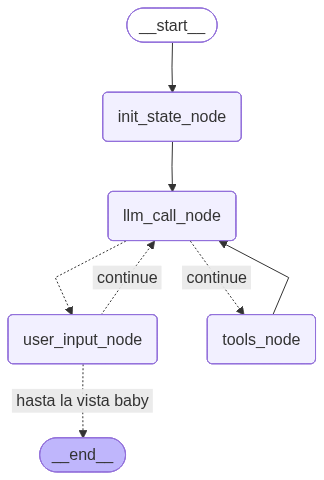

In [5]:
graph